In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# current path root dir, then train dir, then MapUtils dir
PROJECT_ROOT = os.getcwd()
TRAIN_DIR = os.path.join(PROJECT_ROOT, "ECE5242Proj3-train")
MAPUTILS_CYTHON_DIR = os.path.join(TRAIN_DIR, "MapUtilsCython")

if TRAIN_DIR not in sys.path:
    sys.path.append(TRAIN_DIR)
if MAPUTILS_CYTHON_DIR not in sys.path:
    sys.path.append(MAPUTILS_CYTHON_DIR)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("TRAIN_DIR    =", TRAIN_DIR)
print("MAPUTILS_DIR =", MAPUTILS_CYTHON_DIR)

PROJECT_ROOT = C:\Users\Tiger\Desktop\ECE5242 Project 3
TRAIN_DIR    = C:\Users\Tiger\Desktop\ECE5242 Project 3\ECE5242Proj3-train
MAPUTILS_DIR = C:\Users\Tiger\Desktop\ECE5242 Project 3\ECE5242Proj3-train\MapUtilsCython


In [2]:
import numpy as np
import matplotlib.pyplot as plt

import load_data # load_data.py
import MapUtils_fclad as MapUtils  # MapUtilsCython

### 1. Load Sensor data

In [3]:
# load_data.py - get_encoder(file_name)
# load_data.py - get_lidar(file_name)
# print shape / sample / timestamp
# 数据读取器

# Encoders.mat: timestamp and values (4 channel count data)
# Hokuyo.mat: Lidar scan data
# imu.mat: acceleration and angular velocty

# dataset 例子!!!!!!!!!
data_id = 20 # 20,21,23

encoder_path = os.path.join(TRAIN_DIR, "data", f"Encoders{data_id}")
lidar_path = os.path.join(TRAIN_DIR, "data", f"Hokuyo{data_id}")
imu_path = os.path.join(TRAIN_DIR, "data", f"imu{data_id}")

In [4]:
# load encoder / lidar / imu
# enc_ts = encoder timestamps 每次读到编码器数据的时间stamp
FL, FR, RL, RR, enc_ts = load_data.get_encoder(encoder_path)
lidar = load_data.get_lidar(lidar_path)
acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z, imu_ts = load_data.get_imu(imu_path)

print("Encoder length:", len(enc_ts))
print("Lidar frames:", len(lidar))
print("IMU length:", len(imu_ts))

Encoder length: 4956
Lidar frames: 4962
IMU length: 12187


### 2. Encoder Odometry 里程计
- convert encoder counts into wheel travel distance
- average front and rear wheels on each side, and compute robot motion increment (x,y,θ)

suggestions.txt 2 : Try dead-reckoning with encoder data and plot the robot trajectory

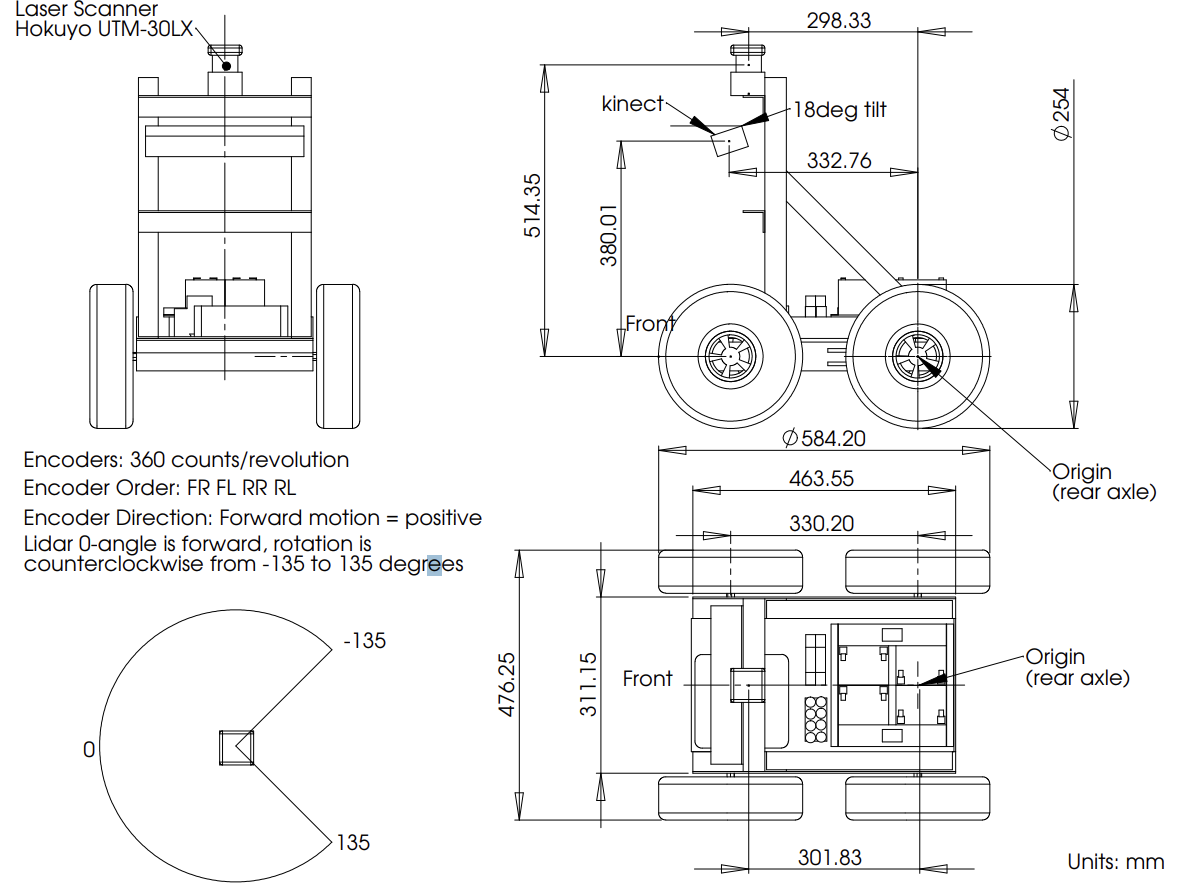

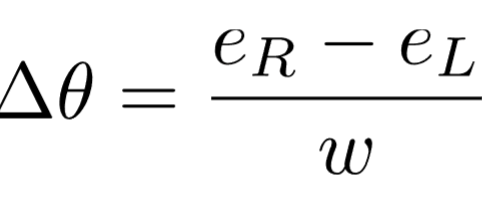

In [5]:
# count → wheel distance → robot motion increment → pose trajectory

# robot parameters
counts_per_revolution = 360.0 # count per revolution 每转一圈多少count
wheel_diameter = 0.254 # meters (254mm)
track_width = 0.735 #履带/左右轮子宽度 # 微调, 2X of range 0.5*(0.47625 + 0.31115)

# each 'count' is wheel moving forward distance
distance_per_count = np.pi * wheel_diameter / counts_per_revolution


# encoder counts -> wheel travel distance for each timestep 第i个时间step, 轮子走了多少米
FL_step = FL * distance_per_count
FR_step = FR * distance_per_count
RL_step = RL * distance_per_count
RR_step = RR * distance_per_count

# average left/right wheel travel
left_side_distance = 0.5*(FL_step + RL_step)
right_side_distance = 0.5*(FR_step + RR_step)

# robot increment motion
d_forward = 0.5*(left_side_distance + right_side_distance) # 第i个时间step, robot center走了多少米
d_theta = (right_side_distance - left_side_distance) / track_width


# suggestions.txt 2 : Try dead-reckoning with encoder data and plot the robot trajectory
# pose trajectory 位姿轨迹 (x,y,θ)
x = np.zeros(len(enc_ts))
y = np.zeros(len(enc_ts))
theta = np.zeros(len(enc_ts))

# trajectory cumulate 某一帧对应的单个数值
for i in range(1, len(enc_ts)):
    theta_mid = theta[i-1] + 0.5 * d_theta[i-1]
    x[i] = x[i-1] + d_forward[i-1] * np.cos(theta_mid)
    y[i] = y[i-1] + d_forward[i-1] * np.sin(theta_mid)
    theta[i] = theta[i-1] + d_theta[i-1]

print("final pose =", x[-1], y[-1], theta[-1])

final pose = -0.3616310235572864 -2.1326000886582546 0.13420038459380232


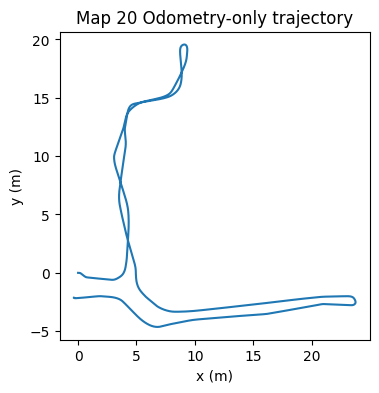

In [6]:
# plot
plt.figure(figsize=(4, 4))
plt.plot(x, y)
plt.axis("equal")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title(f"Map {data_id} Odometry-only trajectory")
plt.show()

### 3. one lidar scan -> xy points
suggestions.txt 3: Try mapping from the first scan and plot the map

scan shape: (1081,)
angles shape: (1081,)
scan_valid shape: (1032,)
angles_valid shape: (1032,)


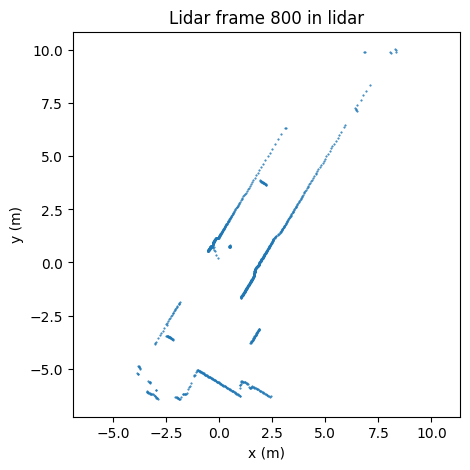

In [7]:
frame_id = 800 # 帧

# scan[i] angles[i] 第i根激光束的距离 &方向
# reshape(-1) press to 1 Demension
scan = np.asarray(lidar[frame_id]['scan']).reshape(-1)
angles = np.asarray(lidar[frame_id]['angle']).reshape(-1)

valid = (scan > 0.2) & (scan < 15.0) # valid beam range
scan_valid = scan[valid]
angles_valid = angles[valid]

# (r,θ) -> (x,y)
x_lidar = scan_valid * np.cos(angles_valid)
y_lidar = scan_valid * np.sin(angles_valid)

print("scan shape:", scan.shape)
print("angles shape:", angles.shape)
print("scan_valid shape:", scan_valid.shape)
print("angles_valid shape:", angles_valid.shape)

plt.figure(figsize=(5,5))
plt.plot(x_lidar, y_lidar, '.', markersize=1)
plt.axis('equal')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title(f'Lidar frame {frame_id} in lidar')
plt.show()

### 4. Occupacncy grid Mapping
odometry pose + lidar frame -> occupancy map

suggestions.txt 4: Try occupancy grid map and update the map with new scan data

- `map_resolution`：Size of each grid in meter (每个格子多大，单位米

- `map_x_min_in_meters`, `map_x_max_in_meters`: map x range (地图 x 范围
- `map_y_min_in_meters`, `map_y_max_in_meters`: map y range (地图 y 范围
- `map_size_x_in_cells`, `map_size_y_in_cells`: How many grid in map (地图有多少格

Use 2-D array to store map 用一个二维数组存地图:
- `grid_map[cell_x_index, cell_y_index]`

Whenever a lidar dot fall into one grid 每当有一个 lidar 点落到某个格子,就：
- `grid_map[cell_x_index, cell_y_index]` += 1

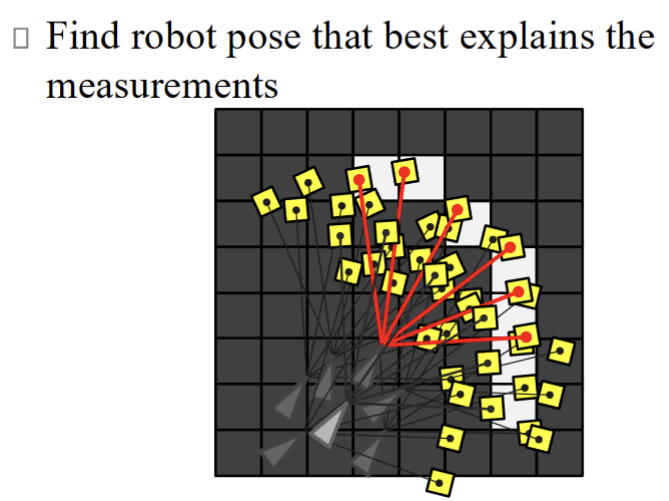

#### hit map -> ray pass middle grid: free space / ray end point grid: occupied / log-odds update

In [8]:
# assume a 25m x 25m square map
# define map range and resolution
map_resolution = 0.02 # meter (each grid cell is 0.02m)
map_x_min_in_meters = -25.0
map_x_max_in_meters = 25.0
map_y_min_in_meters = -25.0
map_y_max_in_meters = 25.0

# how many cells created based on resolution
map_size_x_in_cells = int(np.ceil((map_x_max_in_meters - map_x_min_in_meters)/map_resolution)) + 1
map_size_y_in_cells = int(np.ceil((map_y_max_in_meters - map_y_min_in_meters)/map_resolution)) + 1


Occupancy grid with odometry

- hit-count map
- free space map
- log-odds map

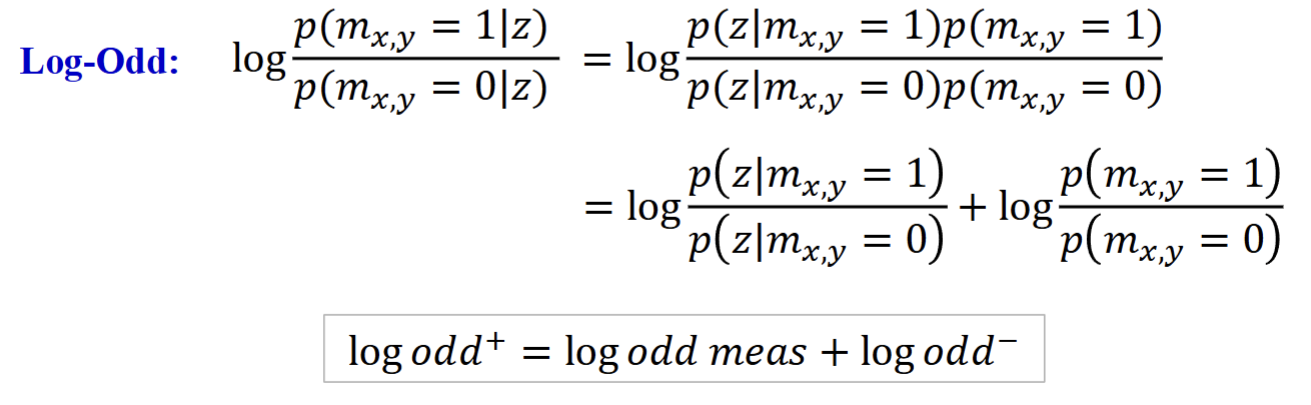

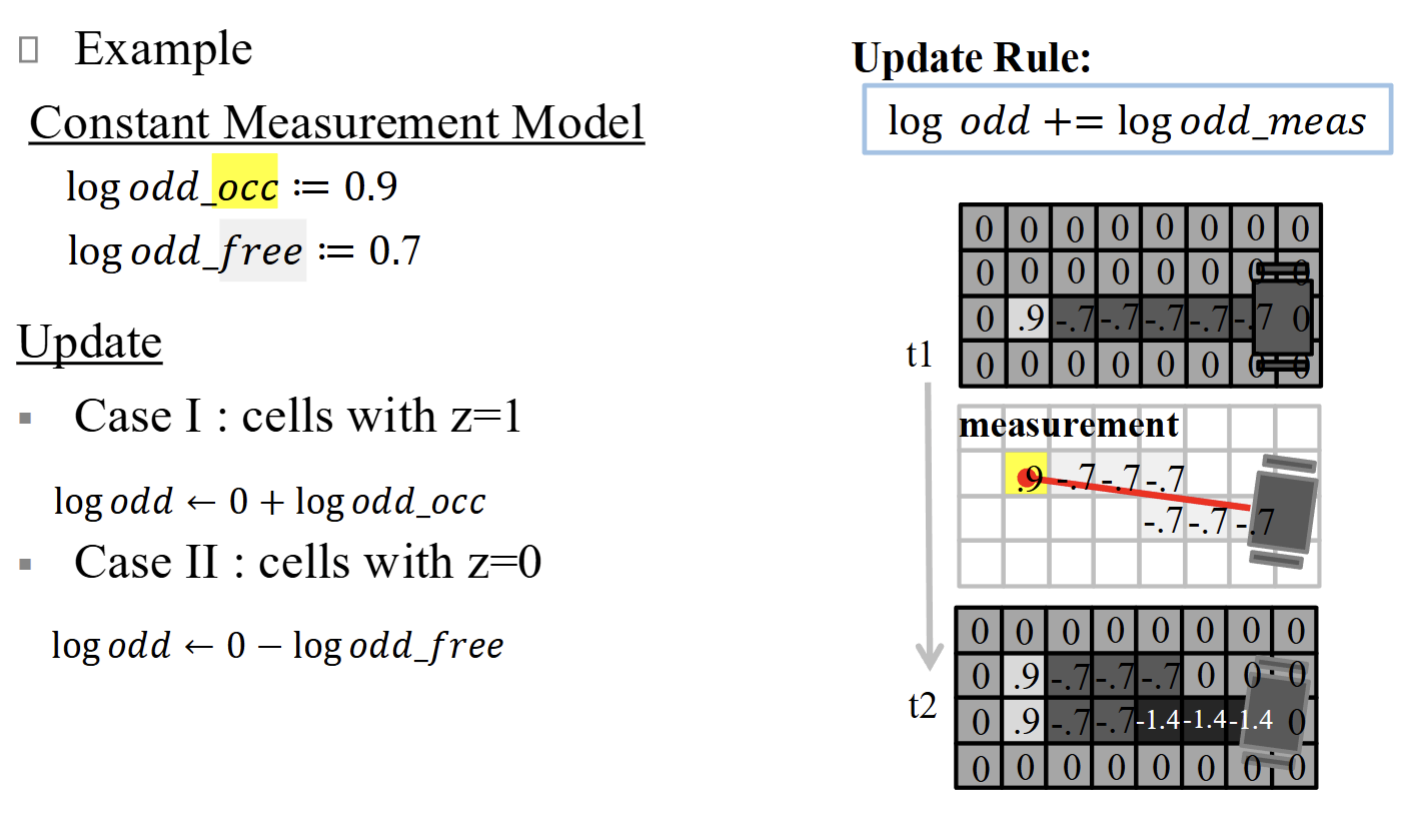

In [9]:
# each cell stores a log-odds occupancy value
occupancy_log_odds_map = np.zeros((map_size_x_in_cells, map_size_y_in_cells), dtype=np.float32)


# new parameters from file "Tips for tuning SLAM hyperparameters"
# Log-odds increase for a “hit”: Play with this value in the range 0-1
# Log-odds decrease for a “miss”: Play with this value in the range 0-1
# Min/Max cap for map log-odd: Play with this value in the range 1-30

hit_log_odds = 0.7 # more like obstacle wall, more black
miss_log_odds = 0.2 # more like free space, more white
log_odds_cap = 5.0 # keep log-odds finite, not infinite

In [10]:
# world frame points (in meters) 坐标 -> map格子
def world_to_map_indexs(x_in_world, y_in_world):
    x_cell_index = np.floor((x_in_world - map_x_min_in_meters) / map_resolution).astype(int)
    y_cell_index = np.floor((y_in_world - map_y_min_in_meters) / map_resolution).astype(int)

    return x_cell_index, y_cell_index



# 输入 一帧scan + 机器人pose, 输出所有 hit点在世界坐标位置
# one frame scan + robot pose, output all hit point in world frame points (in meters)
def lidar_points_in_world_frame(scan_in_meters, angles_in_radians, robot_x_in_world,
                                robot_y_in_world, robot_theta_in_world):

    scan_in_meters = scan_in_meters[::10]
    angles_in_radians = angles_in_radians[::10]

    # keep valid lidar beams 激光可能打到自己,调小range减少扇形
    valid = (scan_in_meters > 0.2) & (scan_in_meters < 15.0) # valid beam range

    valid_scan_in_meters  = scan_in_meters [valid]
    valid_angles_in_radians  = angles_in_radians[valid]

    # polar(r,θ) -> (x,y), lidar_frame 激光雷达自己为原点的坐标系
    x_lidar_frame = valid_scan_in_meters  * np.cos(valid_angles_in_radians)
    y_lidar_frame = valid_scan_in_meters  * np.sin(valid_angles_in_radians)

    # lidar frame points -> world frame points 雷达数据点 -> 世界坐标点
    cos_theta = np.cos(robot_theta_in_world)
    sin_theta = np.sin(robot_theta_in_world)

    x_points_in_world = (
        robot_x_in_world
        + cos_theta * x_lidar_frame
        - sin_theta * y_lidar_frame
    )

    y_points_in_world = (
        robot_y_in_world
        + sin_theta * x_lidar_frame
        + cos_theta * y_lidar_frame
    )

    return x_points_in_world, y_points_in_world
    

In [11]:
# 用一帧 lidar 更新 occupancy map
# one lidar frame to update occupancy map

def update_occupancy_log_odds_map(occupancy_log_odds_map,
                                  robot_x_in_world, robot_y_in_world,
                                  x_points_in_world, y_points_in_world):
    
    # robot position -> map cell 机器人位置转格子
    robot_x_cell_index, robot_y_cell_index = world_to_map_indexs(robot_x_in_world, robot_y_in_world)

    # robot outside map 出界
    if not (0 <= robot_x_cell_index < map_size_x_in_cells and 0 <= robot_y_cell_index < map_size_y_in_cells):
        return occupancy_log_odds_map

    # lidar hit points -> map cells
    x_cell_indexs, y_cell_indexs = world_to_map_indexs(x_points_in_world, y_points_in_world)

    # keep only points inside map
    inside_map = (
        (x_cell_indexs >= 0) & (x_cell_indexs < map_size_x_in_cells) &
        (y_cell_indexs >= 0) & (y_cell_indexs < map_size_y_in_cells)
    )

    valid_x_cell_indexs = x_cell_indexs[inside_map]
    valid_y_cell_indexs = y_cell_indexs[inside_map]

    if len(valid_x_cell_indexs) == 0:
        return occupancy_log_odds_map


    # MapUtilsCython - getMapCellsFromRay_fclad(xrobot,yrobot,xends,yends, maxMap):
    # free cells along the ray 激光中途经过的cell
    free_cell_indexs = MapUtils.getMapCellsFromRay_fclad(
        int(robot_x_cell_index),
        int(robot_y_cell_index),
        valid_x_cell_indexs.astype(np.int16),
        valid_y_cell_indexs.astype(np.int16),
        max(map_size_x_in_cells, map_size_y_in_cells)
    )

    if free_cell_indexs.shape[1] > 0:
        free_x_cell_indexs = free_cell_indexs[0, :].astype(int)
        free_y_cell_indexs = free_cell_indexs[1, :].astype(int)

        valid_free = (
            (free_x_cell_indexs >= 0) & (free_x_cell_indexs < map_size_x_in_cells) &
            (free_y_cell_indexs >= 0) & (free_y_cell_indexs < map_size_y_in_cells)
        )

        # free cells minus 减分
        occupancy_log_odds_map[
            free_x_cell_indexs[valid_free],
            free_y_cell_indexs[valid_free]
        ] -= miss_log_odds

    # hit cells add 加分
    occupancy_log_odds_map[
        valid_x_cell_indexs,
        valid_y_cell_indexs
    ] += hit_log_odds

    # clip
    occupancy_log_odds_map = np.clip(
        occupancy_log_odds_map,
        -log_odds_cap,
        log_odds_cap
    )

    return occupancy_log_odds_map

In [12]:
# loop over lidar frames

# update rules:
# cells at lidar endpoints are treated as hits
# cells along the beam ray are treated as free space / misses
# hit cells: increase log-odds
# free cells: decrease log-odds
# then clip log-odds to keep values bounded

for lidar_frame_index in range(0, len(lidar),3):

    # one lidar scan -> xy points
    # current lidar scan
    lidar_scan_ranges_in_meters = np.asarray(lidar[lidar_frame_index]['scan']).reshape(-1)
    lidar_scan_angles_in_radians = np.asarray(lidar[lidar_frame_index]['angle']).reshape(-1)
    
    # nearest odometry pose by timestamp 按时间戳查找最近的里程计位姿
    # robot pose in world_frame 全局地图坐标系
    lidar_timestamp = lidar[lidar_frame_index]['t']
    closest_encoder_index = np.argmin(np.abs(enc_ts - lidar_timestamp))
    
    robot_x_in_world = x[closest_encoder_index]
    robot_y_in_world = y[closest_encoder_index]
    robot_theta_in_world = theta[closest_encoder_index]

    # 用一帧 lidar 更新 occupancy map [function]
    # one lidar frame to update occupancy grid map
    x_points_in_world, y_points_in_world = lidar_points_in_world_frame(
        lidar_scan_ranges_in_meters, lidar_scan_angles_in_radians,
        robot_x_in_world, robot_y_in_world, robot_theta_in_world)

    occupancy_log_odds_map = update_occupancy_log_odds_map(
        occupancy_log_odds_map, robot_x_in_world, robot_y_in_world,
        x_points_in_world, y_points_in_world)
    

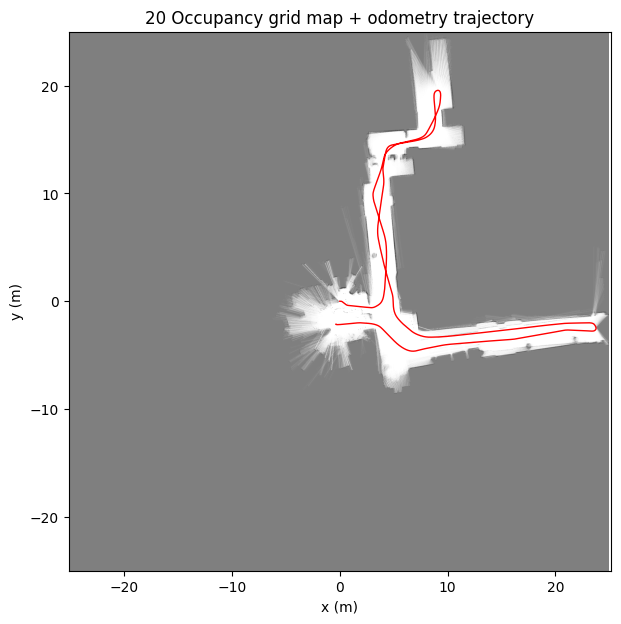

In [13]:
# plot

occupancy_probability_map = 1.0 - 1.0 / (1.0 + np.exp(occupancy_log_odds_map))

plt.figure(figsize=(7, 7))
plt.imshow(
    occupancy_probability_map.T,
    origin='lower',
    extent=[
        map_x_min_in_meters,
        map_x_max_in_meters,
        map_y_min_in_meters,
        map_y_max_in_meters
    ],
    cmap='gray_r'
)

plt.plot(x, y, 'r-', linewidth=1)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title(f'{data_id} Occupancy grid map + odometry trajectory')
plt.axis('equal')
plt.show()

### 5. Particle filter SLAM Map
Rate and use the best particle to update map

odometry pose更新地图->变成->先在odometry pose附近放几个粒子,选最好的那个粒子,再用它更新地图

suggestions.txt 5: Try prediction only and plot the robot trajectories (100 for N=100 particles)

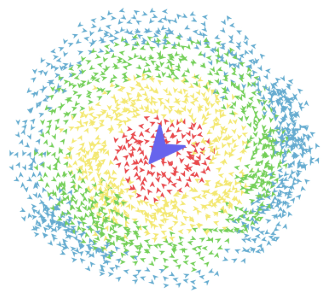 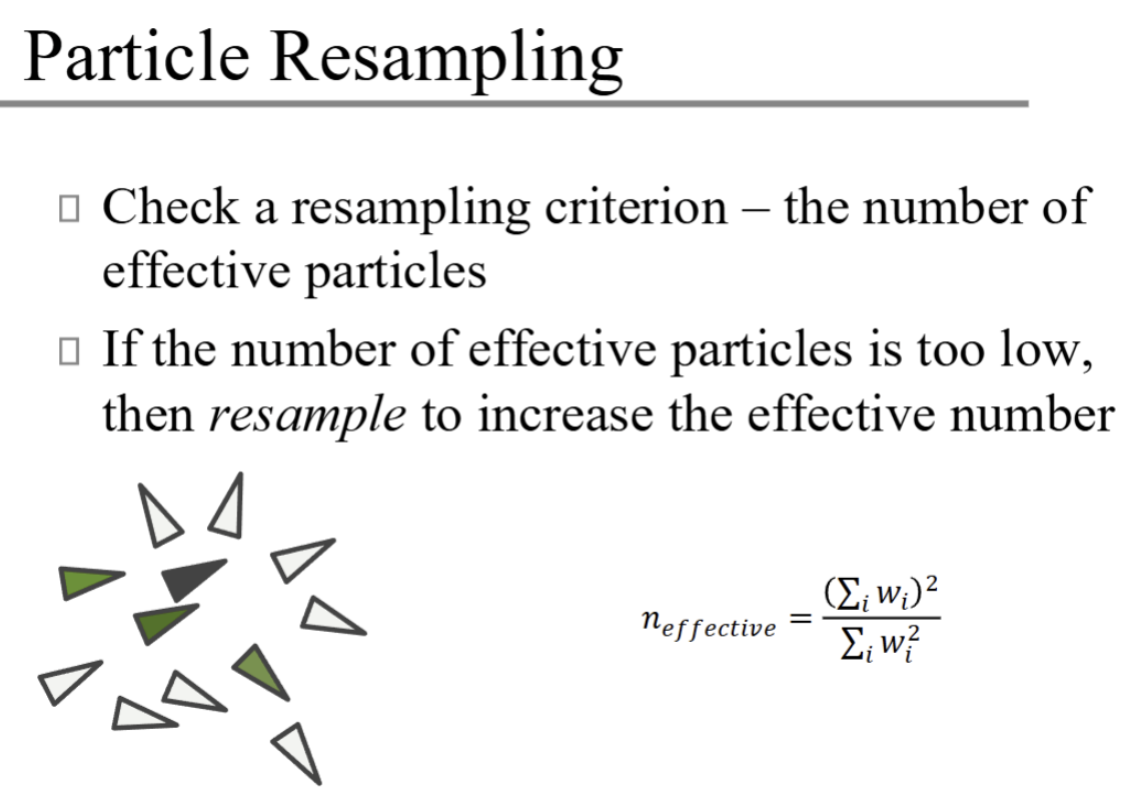

#### odometry-based mapping -> changed to -> full particle-filter SLAM mapping

changed from

- nearest odometry pose
- lidar_points_in_world_frame(...)
- update_occupancy_log_odds_map(...)

to

- odometry increment 机器人走了多少米 delta_x/y/θ = x/y/θ_cur - x/y/θ_prev
- particle prediction
- particle scoring / weights
- best particle pose
- lidar_points_in_world_frame(...)
- update_occupancy_log_odds_map(...)

In [14]:
# cumulate angle limit to -> [-π, π)
def wrap_angle(angle):
    return (angle + np.pi) % (2.0 * np.pi) - np.pi

# 有多少个粒子还真的在参与表示分布
# n_effective function, if normalized sum(weight)=1, it's equal to 1/ np.sum(weights ** 2)
def effective_particle_number(weights):
    return (np.sum(weights) ** 2) / np.sum(weights ** 2)

# copy particles according to its weights, and pass bad particles 按粒子权重复制好粒子,淘汰差粒子
def systematic_resample(weights):
    n = len(weights)
    positions = (np.arange(n) + np.random.rand()) / n

    indexes = np.zeros(n, dtype=int)
    cumulative_sum = np.cumsum(weights) # vector 变 cdf

    i = 0 # current sample point positions[i] 粒子位置
    j = 0 # current particle range cumulative_sum[j] 粒子区间
    while i < n:
        if positions[i] < cumulative_sum[j]: # 采样点落在第 j 个粒子的区间里
            indexes[i] = j
            i += 1
        else:
            j += 1 # 看下一个区间

    return indexes

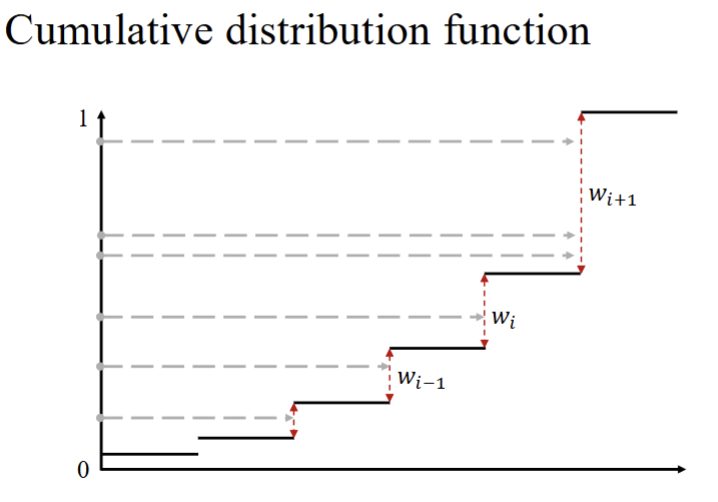
cumulative_sum = np.cumsum(weights) # vector 变 cdf

In [15]:
def score_particle(scan_in_meters, angles_in_radians,
                   particle_x_in_world, particle_y_in_world,
                   particle_theta_in_world, occupancy_log_odds_map):
        
    x_points_in_world, y_points_in_world = lidar_points_in_world_frame(scan_in_meters, angles_in_radians,
                                                                       particle_x_in_world, particle_y_in_world,
                                                                       particle_theta_in_world)

    x_cell_indexs, y_cell_indexs = world_to_map_indexs(x_points_in_world, y_points_in_world)

    inside_map = (
        (x_cell_indexs >= 0) & (x_cell_indexs < map_size_x_in_cells) &
        (y_cell_indexs >= 0) & (y_cell_indexs < map_size_y_in_cells)
    )

    valid_x_cell_indexs = x_cell_indexs[inside_map]
    valid_y_cell_indexs = y_cell_indexs[inside_map]

    if len(valid_x_cell_indexs) == 0:
        return -1e9

    score = np.sum(occupancy_log_odds_map[valid_x_cell_indexs, valid_y_cell_indexs])

    return score

In [16]:
num_particles = 100 # range[30,100]
# each particle is a pose hypothesis (x, y, theta)
particles = np.zeros((num_particles, 3), dtype=np.float64)
weights = np.ones(num_particles, dtype=np.float64) / num_particles # initial all weights to be equal

# New map created, to compare with odometry-only
slam_occupancy_log_odds_map = np.zeros_like(occupancy_log_odds_map)

# save best particle trajectory
slam_x = []
slam_y = []
slam_theta = []

# motion noise 运动噪声
forward_noise_std = 0.008
theta_noise_std = 0.0025

In [17]:
# loop over lidar frames
# Use particle-filter SLAM

# for each particle, project the current lidar scan into the world
# convert those hit points into map cells
# score the particle using the current occupancy map
# score is sum of map log-odds values at the projected scan endpoints 扫描点处地图对数概率的总和

# particle loop, start from warup_frames index
for lidar_frame_index in range(3, len(lidar),3): # 第三帧开始

    # 1. one lidar scan -> xy points
    # current lidar scan
    lidar_scan_ranges_in_meters = np.asarray(lidar[lidar_frame_index]['scan']).reshape(-1)
    lidar_scan_angles_in_radians = np.asarray(lidar[lidar_frame_index]['angle']).reshape(-1)
    
    current_lidar_timestamp = lidar[lidar_frame_index]['t']
    previous_lidar_timestamp = lidar[lidar_frame_index - 3]['t']
    
    # 2. nearest odometry poses 最近的 encoder时刻
    current_encoder_index = np.argmin(np.abs(enc_ts - current_lidar_timestamp))
    previous_encoder_index = np.argmin(np.abs(enc_ts - previous_lidar_timestamp))

    # 3. odometry increment 机器人走了多少米 delta_x/y/θ = x/y/θ_cur - x/y/θ_prev
    delta_x = x[current_encoder_index] - x[previous_encoder_index]
    delta_y = y[current_encoder_index] - y[previous_encoder_index]
    delta_theta = wrap_angle(theta[current_encoder_index] - theta[previous_encoder_index])

    delta_forward = np.sqrt(delta_x**2 + delta_y**2)

    # 4. prediction：particles are propagated using odometry + motion noise 每个粒子都往前走一点
    for particle_index in range(num_particles):
        particle_x_in_world = particles[particle_index, 0]
        particle_y_in_world = particles[particle_index, 1]
        particle_theta_in_world = particles[particle_index, 2]

        noisy_forward = delta_forward + np.random.randn() * forward_noise_std
        noisy_theta = delta_theta + np.random.randn() * theta_noise_std

        

        theta_mid = particle_theta_in_world + 0.5 * noisy_theta

        particles[particle_index, 0] = particle_x_in_world + noisy_forward * np.cos(theta_mid)
        particles[particle_index, 1] = particle_y_in_world + noisy_forward * np.sin(theta_mid)
        particles[particle_index, 2] = wrap_angle(particle_theta_in_world + noisy_theta)

    
    # 5. update: score every particle
    particle_scores = np.zeros(num_particles) 

    for particle_index in range(num_particles):
        particle_scores[particle_index] = score_particle(
            lidar_scan_ranges_in_meters,
            lidar_scan_angles_in_radians,
            particles[particle_index, 0],
            particles[particle_index, 1],
            particles[particle_index, 2],
            slam_occupancy_log_odds_map
        )

    
    # 6. score -> weight 分数 -> 权重
    particle_scores = particle_scores - np.max(particle_scores)
    weights = weights * np.exp(particle_scores) # particle_likelihoods = np.exp(particle_scores)
    weights = weights + 1e-300
    weights = weights / np.sum(weights)

    
    # 7. 找最好的粒子
    best_particle_index = np.argmax(weights)

    best_x_in_world = particles[best_particle_index, 0]
    best_y_in_world = particles[best_particle_index, 1]
    best_theta_in_world = particles[best_particle_index, 2]
    
    slam_x.append(best_x_in_world)
    slam_y.append(best_y_in_world)
    slam_theta.append(best_theta_in_world)


    # 8. 用最好粒子更新地图
    x_points_in_world, y_points_in_world = lidar_points_in_world_frame(
        lidar_scan_ranges_in_meters, lidar_scan_angles_in_radians,
        best_x_in_world, best_y_in_world, best_theta_in_world
    )

    slam_occupancy_log_odds_map = update_occupancy_log_odds_map(
        slam_occupancy_log_odds_map,
        best_x_in_world, best_y_in_world,
        x_points_in_world, y_points_in_world
    )

    
    # 9. if drops too low, perform systematic resampling 如果有效粒子太少，就重采样
    n_effective = effective_particle_number(weights)

    if n_effective < 0.5 * num_particles:
        resample_indexes = systematic_resample(weights)
        particles = particles[resample_indexes]
        weights = np.ones(num_particles, dtype=np.float64) / num_particles

    # if lidar_frame_index % 300 == 0:
    #     print("frame =", lidar_frame_index, "n_effective =", n_effective)    

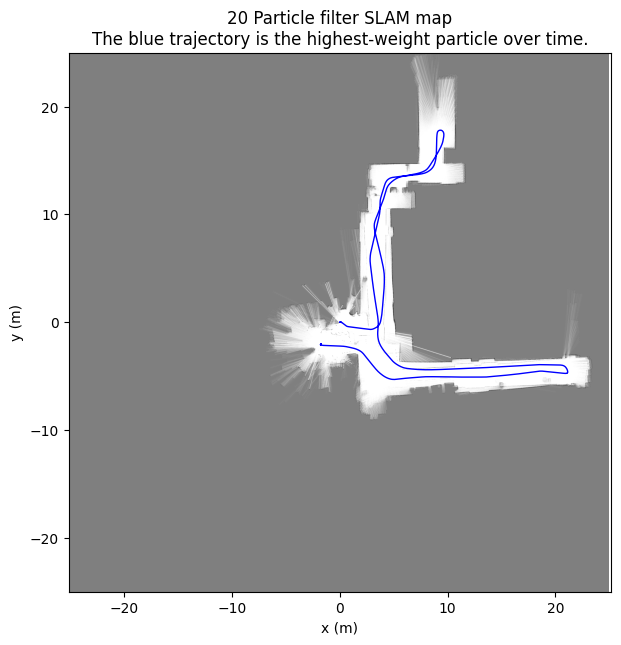

In [18]:
# plot
slam_occupancy_probability_map = 1.0 - 1.0 / (1.0 + np.exp(slam_occupancy_log_odds_map))

plt.figure(figsize=(7, 7))
plt.imshow(
    slam_occupancy_probability_map.T,
    origin='lower',
    extent=[
        map_x_min_in_meters,
        map_x_max_in_meters,
        map_y_min_in_meters,
        map_y_max_in_meters
    ],
    cmap='gray_r'
)

plt.plot(slam_x, slam_y, 'b-', linewidth=1)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title(f'{data_id} Particle filter SLAM map\nThe blue trajectory is the highest-weight particle over time.')
plt.axis('equal')
plt.show()

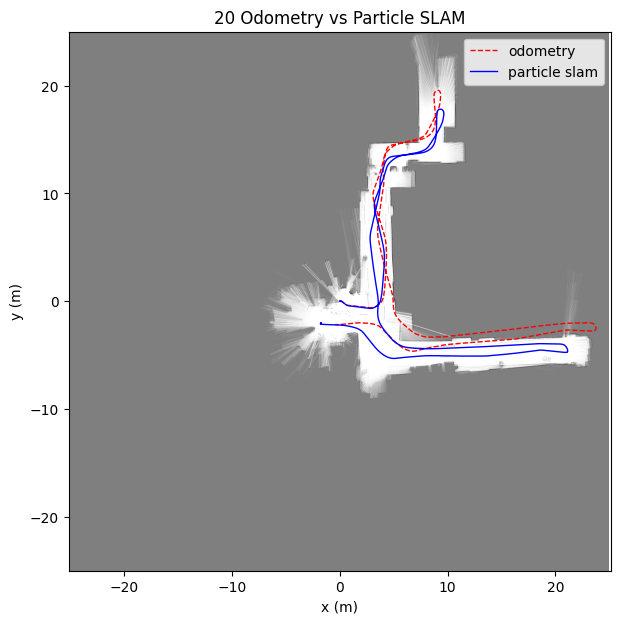

In [19]:
plt.figure(figsize=(7, 7))
plt.imshow(
    slam_occupancy_probability_map.T,
    origin='lower',
    extent=[
        map_x_min_in_meters,
        map_x_max_in_meters,
        map_y_min_in_meters,
        map_y_max_in_meters
    ],
    cmap='gray_r'
)

plt.plot(x, y, 'r--', linewidth=1, label='odometry')
plt.plot(slam_x, slam_y, 'b-', linewidth=1, label='particle slam')

plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title(f'{data_id} Odometry vs Particle SLAM')
plt.axis('equal')
plt.legend()
plt.show()